In [1]:
import os
import json
import time
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


###  Config

In [2]:
SHARED_DATASET_FILE = "../data/processed/cleaned_emotions_shared.csv"
SHARED_SPLIT_FILE   = "../data/splits/shared_split.json"

DL_MODEL_FILE    = "../models/bilstm_model.keras"
TOKENIZER_FILE   = "../models/tokenizer.json"
LABEL_MAP_FILE   = "../models/label_mapping.json"
DL_METADATA_FILE = "../models/dl_metadata.json"
DL_PRED_FILE     = "../data/processed/dl_test_predictions.csv"
DL_SUMMARY_FILE  = "../data/processed/dl_summary.csv"

MAX_VOCAB_SIZE = 10000
MAX_LEN = 50
EMBED_DIM = 128
LSTM_UNITS = 64
BATCH_SIZE = 16
EPOCHS = 10

os.makedirs("../models", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

total_start_time = time.time()

### Load data

In [3]:
df = pd.read_csv(SHARED_DATASET_FILE)

with open(SHARED_SPLIT_FILE, "r", encoding="utf-8") as f:
    split_dict = json.load(f)

train_df = df[df["row_id"].isin(split_dict["train_ids"])].copy()
val_df   = df[df["row_id"].isin(split_dict["val_ids"])].copy()
test_df  = df[df["row_id"].isin(split_dict["test_ids"])].copy()

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

print("\nTotal emotion classes:", df["label"].nunique())
print("Emotion labels:", sorted(df["label"].unique().tolist()))

print("\nAll data label counts:")
print(df["label"].value_counts().sort_index())

print("\nTrain label counts:")
print(train_df["label"].value_counts().sort_index())

print("\nVal label counts:")
print(val_df["label"].value_counts().sort_index())

print("\nTest label counts:")
print(test_df["label"].value_counts().sort_index())

Train: (1512, 3)
Val  : (324, 3)
Test : (324, 3)

Total emotion classes: 6
Emotion labels: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad']

All data label counts:
label
angry      326
disgust    427
fear       395
happy      234
neutral    500
sad        278
Name: count, dtype: int64

Train label counts:
label
angry      228
disgust    299
fear       276
happy      164
neutral    350
sad        195
Name: count, dtype: int64

Val label counts:
label
angry      49
disgust    64
fear       59
happy      35
neutral    75
sad        42
Name: count, dtype: int64

Test label counts:
label
angry      49
disgust    64
fear       60
happy      35
neutral    75
sad        41
Name: count, dtype: int64


### Tokenizer

In [4]:
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df["text"])

X_train = tokenizer.texts_to_sequences(train_df["text"])
X_val   = tokenizer.texts_to_sequences(val_df["text"])
X_test  = tokenizer.texts_to_sequences(test_df["text"])

X_train_pad = pad_sequences(X_train, maxlen=MAX_LEN, padding="post", truncating="post")
X_val_pad   = pad_sequences(X_val, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test, maxlen=MAX_LEN, padding="post", truncating="post")

### Labels

In [5]:
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(train_df["label"])
y_val   = label_encoder.transform(val_df["label"])
y_test  = label_encoder.transform(test_df["label"])

num_classes = len(label_encoder.classes_)

y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat   = to_categorical(y_val, num_classes=num_classes)
y_test_cat  = to_categorical(y_test, num_classes=num_classes)

print("\nClasses:", label_encoder.classes_)
print("Number of classes:", num_classes)


Classes: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad']
Number of classes: 6


### Model

In [6]:
vocab_size = min(MAX_VOCAB_SIZE, len(tokenizer.word_index) + 1)

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(LSTM_UNITS)),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Train

In [7]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

train_start = time.time()

history = model.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

train_elapsed = time.time() - train_start
print(f"\nTraining time: {train_elapsed:.2f} seconds")


Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.3882 - loss: 1.5459 - val_accuracy: 0.5340 - val_loss: 1.2150
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7540 - loss: 0.7783 - val_accuracy: 0.8488 - val_loss: 0.4666
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9028 - loss: 0.3196 - val_accuracy: 0.8920 - val_loss: 0.2998
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9544 - loss: 0.1645 - val_accuracy: 0.8827 - val_loss: 0.3047
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9663 - loss: 0.1119 - val_accuracy: 0.8827 - val_loss: 0.3324
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9802 - loss: 0.0628 - val_accuracy: 0.9012 - val_loss: 0.2978
Epoch 7/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9821 - loss: 0.0649 - val_accuracy: 0.9074 - val_loss: 0.3366
Epoch 8/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9947 - loss: 0.0298 - val_accuracy: 0.9043 - v

### Evaluate

In [8]:
test_pred_prob = model.predict(X_test_pad, verbose=0)
test_pred_classes = np.argmax(test_pred_prob, axis=1)
test_pred_labels = label_encoder.inverse_transform(test_pred_classes)
test_true_labels = label_encoder.inverse_transform(y_test)

acc = accuracy_score(test_true_labels, test_pred_labels)
f1_macro = f1_score(test_true_labels, test_pred_labels, average="macro")
f1_weighted = f1_score(test_true_labels, test_pred_labels, average="weighted")

print("\n===== DL RESULT =====")
print("Accuracy    :", acc)
print("F1 Macro    :", f1_macro)
print("F1 Weighted :", f1_weighted)
print("\nClassification Report:")
print(classification_report(test_true_labels, test_pred_labels))
print("Confusion Matrix:")
print(confusion_matrix(test_true_labels, test_pred_labels))



===== DL RESULT =====
Accuracy    : 0.8950617283950617
F1 Macro    : 0.9071021991872712
F1 Weighted : 0.8928500602174343

Classification Report:
              precision    recall  f1-score   support

       angry       0.92      1.00      0.96        49
     disgust       0.89      0.92      0.91        64
        fear       0.86      0.72      0.78        60
       happy       1.00      0.97      0.99        35
     neutral       0.83      0.85      0.84        75
         sad       0.93      1.00      0.96        41

    accuracy                           0.90       324
   macro avg       0.91      0.91      0.91       324
weighted avg       0.89      0.90      0.89       324

Confusion Matrix:
[[49  0  0  0  0  0]
 [ 0 59  1  0  1  3]
 [ 2  3 43  0 12  0]
 [ 0  0  1 34  0  0]
 [ 2  4  5  0 64  0]
 [ 0  0  0  0  0 41]]


### Save

In [ ]:
model.save(DL_MODEL_FILE)

with open(TOKENIZER_FILE, "w", encoding="utf-8") as f:
    f.write(tokenizer.to_json())

label_mapping = {label: int(i) for i, label in enumerate(label_encoder.classes_)}
with open(LABEL_MAP_FILE, "w", encoding="utf-8") as f:
    json.dump(label_mapping, f, ensure_ascii=False, indent=2)

metadata = {
    "max_sequence_length": MAX_LEN,
    "classes": label_encoder.classes_.tolist(),
    "max_vocab_size": MAX_VOCAB_SIZE,
    "num_classes": num_classes
}
with open(DL_METADATA_FILE, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

pred_df = test_df[["row_id", "text", "label"]].copy()
pred_df["dl_pred"] = test_pred_labels
pred_df["dl_confidence"] = test_pred_prob.max(axis=1)
pred_df.to_csv(DL_PRED_FILE, index=False, encoding="utf-8-sig")

summary_df = pd.DataFrame([{
    "Model": "BiLSTM",
    "Accuracy": acc,
    "F1_Macro": f1_macro,
    รท

    impoasdasd



    asdasdadsdddddddddddddddddddddddddd
    "F1_Weighted": f1_weighted,
    "Train_Time_Seconds": round(train_elapsed, 4),
    "Num_Classes": num_classes
}])

summary_df.to_csv(DL_SUMMARY_FILE, index=False, encoding="utf-8-sig")

print("\n===== Summary =====")
print(summary_df)

total_elapsed = time.time() - total_start_time

print("\nSaved:")
print("-", DL_MODEL_FILE)
print("-", TOKENIZER_FILE)
print("-", LABEL_MAP_FILE)
print("-", DL_METADATA_FILE)
print("-", DL_PRED_FILE)
print("-", DL_SUMMARY_FILE)
print(f"\nTotal DL pipeline time: {total_elapsed:.2f} seconds")
print("Done")


===== Summary =====
    Model  Accuracy  F1_Macro  F1_Weighted  Train_Time_Seconds  Num_Classes
0  BiLSTM  0.895062  0.907102      0.89285             16.6167            6

Saved:
- ../models/bilstm_model.keras
- ../models/tokenizer.json
- ../models/label_mapping.json
- ../models/dl_metadata.json
- ../data/processed/dl_test_predictions.csv
- ../data/processed/dl_summary.csv

Total DL pipeline time: 17.74 seconds
Done


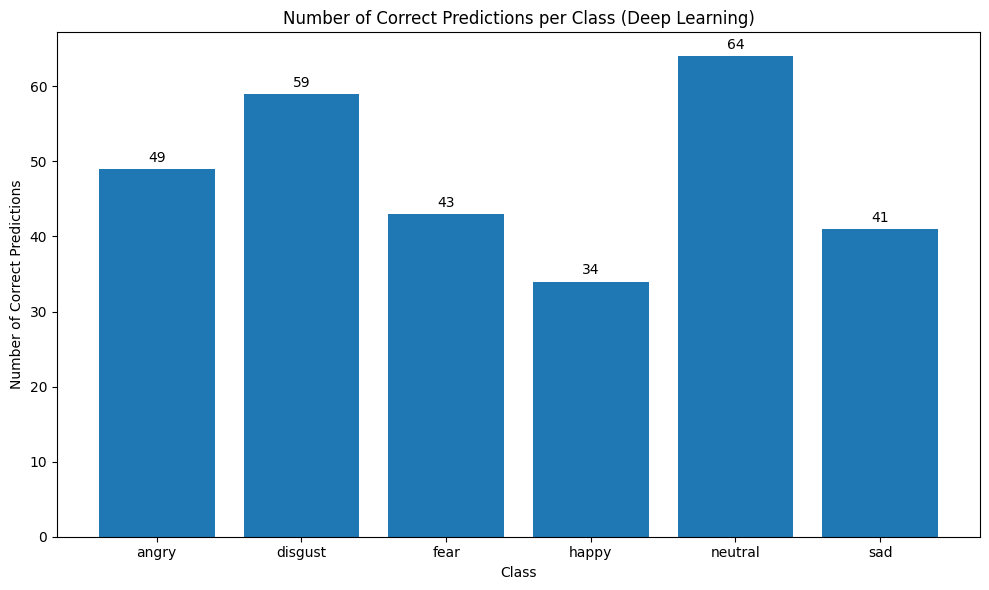

In [10]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["angry", "disgust", "fear", "happy", "neutral", "sad"]

correct_counts = []
for label in labels:
    count = ((pred_df["label"] == label) & (pred_df["dl_pred"] == label)).sum()
    correct_counts.append(count)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(labels, correct_counts, label="BiLSTM")

ax.set_xlabel("Class")
ax.set_ylabel("Number of Correct Predictions")
ax.set_title("Number of Correct Predictions per Class (Deep Learning)")
ax.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()